<a href="https://colab.research.google.com/github/Machine-Learning-Visao-Computacional-T1/CodigosDeAula-Python-Dados-/blob/main/Semana11/KNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

A carregar o dataset real de Vinhos Italianos...
Tamanho da Base: 178 registos e 13 características químicas.



,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0
5,14.20,1.76,2.45,15.2,112.0,3.27,3.39,0.34,1.97,6.75,1.05,2.85,1450.0
6,14.39,1.87,2.45,14.6,96.0,2.50,2.52,0.30,1.98,5.25,1.02,3.58,1290.0
7,14.06,2.15,2.61,17.6,121.0,2.60,2.51,0.31,1.25,5.05,1.06,3.58,1295.0
8,14.83,1.64,2.17,14.0,97.0,2.80,2.98,0.29,1.98,5.20,1.08,2.85,1045.0
9,13.86,1.35,2.27,16.0,98.0,2.98,3.15,0.22,1.85,7.22,1.01,3.55,1045.0


,Tipo_Vinho
0,0
1,0
2,0
3,0
4,0
5,0
6,0
7,0
8,0
9,0


,count
Tipo_Vinho,
1,71
0,59
2,48


A treinar o algoritmo KNN (Mapeando distâncias)...

Relatório de Classificação (Tipos de Vinho: 0, 1 e 2):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       0.94      0.89      0.91        18
           2       0.85      0.92      0.88        12

    accuracy                           0.93        45
   macro avg       0.93      0.94      0.93        45
weighted avg       0.94      0.93      0.93        45



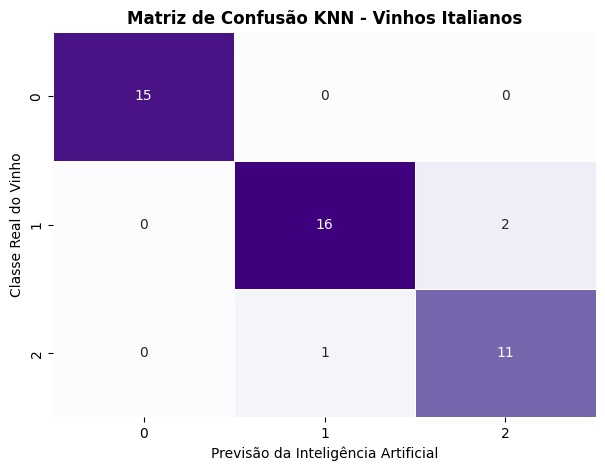

In [ ]:
# ==============================================================================
# LABORATÓRIO: KNN - CLASSIFICAÇÃO DE VINHOS (DADOS REAIS)
# ==============================================================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix

print("A carregar o dataset real de Vinhos Italianos...")

# 1. Carregar os dados nativos do scikit-learn
wine_data = load_wine()
X = pd.DataFrame(wine_data.data, columns=wine_data.feature_names)
y = pd.Series(wine_data.target, name='Tipo_Vinho')

print(f"Tamanho da Base: {X.shape[0]} registos e {X.shape[1]} características químicas.\n")

display(X.head(10))
display(y.head(10))

display(y.value_counts())

# 2. Separação de Treino e Teste (Estratificado para manter as 3 classes de vinho equilibradas)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# 3. Escalonamento Numérico (Crucial para o KNN!)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Instanciar e Treinar o Modelo
print("A treinar o algoritmo KNN (Mapeando distâncias)...")
knn = KNeighborsClassifier(n_neighbors=5, metric='euclidean')
knn.fit(X_train_scaled, y_train)

# 5. Fazer Previsões
previsoes_knn = knn.predict(X_test_scaled)

# 6. Avaliação Numérica
print("\nRelatório de Classificação (Tipos de Vinho: 0, 1 e 2):")
print(classification_report(y_test, previsoes_knn))

# 7. Matriz de Confusão
plt.figure(figsize=(7, 5))
matriz = confusion_matrix(y_test, previsoes_knn)
sns.heatmap(matriz, annot=True, fmt='d', cmap='Purples', linewidths=0.5, cbar=False)
plt.title('Matriz de Confusão KNN - Vinhos Italianos', fontsize=12, fontweight='bold')
plt.ylabel('Classe Real do Vinho', fontsize=10)
plt.xlabel('Previsão da Inteligência Artificial', fontsize=10)
plt.show()